In [1]:
from myutils import cache, clean_all_cache, plot

from src import *
from glob import glob

from src.fisherinfo import FisherInformation, ApproxFisherInformation, FrequencyCFI

In [2]:
@cache
def read_est(A):
    file_tree = [
        f'MLEtest(SIM)/nodelay/sin/*{A}px*',
    ]

    spade_x, spade_y = [], []
    di_x, di_y = [], []

    for file in file_tree:
        for f in glob(file):
            c = LoadEstimates(f) 
            if c.metadata.measurement == 'DI':
                di_x.append(c.metadata.ground_truth)
                di_y.append(c.estimates_a.var(ddof=1) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))
            elif c.metadata.measurement == 'SPADE':
                spade_x.append(c.metadata.ground_truth)
                spade_y.append(c.estimates_a.var(ddof=1) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))

    return np.array(di_x), np.array(di_y), np.array(spade_x), np.array(spade_y)

cache hit: reading result from cache file
cache hit: reading result from cache file


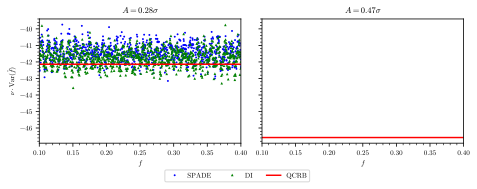

In [7]:
c1 = 'b'
c2 = 'g'

red = 'r'

width = 8.5

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width / 2.54 * 2, width / 2.54 * 1.4 / 2), sharey=True)

for ax in (ax1, ax2):
    A = 3 if ax == ax1 else 5

    x_axis = np.linspace(0.1, 0.4, 1000)

    crb = list(1 / ApproxFisherInformation([A * DMD.PIXEL_SIZE / 2])) * 1000
    crb = 10*np.log10(np.array(crb) * 3.882352941176471)

    di_x, di_y, spade_x, spade_y = read_est(A)

    line1, = ax.plot(spade_x, 10*np.log10(spade_y), 
                    marker='o', linestyle='', markersize=1,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax.plot(di_x, 10*np.log10(di_y),
                    marker='^', linestyle='', markersize=1,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))

    line3, = ax.plot(x_axis, crb, red)
    # ax.plot(x_axis, 0.7 * crb, '-.', color=red)
    # ax.plot(x_axis, 1.3 * crb, '-.', color=red)

    # ax.grid(True, linestyle=':')

    
    ax.set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')

    # ax.fill_between(x_axis, 0.7 * np.array(crb), 1.3 * np.array(crb), color=red, alpha=0.2)

from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    
ax1.set_ylabel(r'$\nu\cdot{\rm Var}(\hat{f})$')
ax1.set_xlabel(r'$f$')
ax2.set_xlabel(r'$f$')

fig.legend([line1, line2, line3], ['SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
# plt.savefig('ideal_sim.pdf')
plt.show()

In [3]:
fim = np.array([[np.arange(50)**2, np.arange(50)], 
                [np.arange(50), np.arange(50)**0]]).sum(-1)

np.linalg.inv(fim)[0, 0] * (np.arange(50)**2).sum()

3.882352941176471